# 🚗 Car Price Prediction

In this project, we use Machine Learning to predict car prices based on mileage.

The main goal of this project is to explore the relationship between mileage and car price and build a Polynomial Regression & Multiple Regression model.

## 📚 Import Libraries

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pl


## 📂 Load Dataset

- In this section, we load the car dataset using Pandas and take a first look at the available data.

In [76]:
df = pd.read_csv('cars.csv')

df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


## 🔎 Data Understanding

- Before building the model, we need to understand the structure of the dataset, its features, data types, and basic statistics.

In [77]:
cdf = df[['brand' , 'model_year' , 'milage' , 'fuel_type' , 'transmission' , 'price']]

info = cdf.info()
des = cdf.describe()
print(info)
print(des)
cdf.head(9)

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model_year    4009 non-null   int64
 2   milage        4009 non-null   str  
 3   fuel_type     3839 non-null   str  
 4   transmission  4009 non-null   str  
 5   price         4009 non-null   str  
dtypes: int64(1), str(5)
memory usage: 188.1 KB
None
        model_year
count  4009.000000
mean   2015.515590
std       6.104816
min    1974.000000
25%    2012.000000
50%    2017.000000
75%    2020.000000
max    2024.000000


,brand,model_year,milage,fuel_type,transmission,price
0,Ford,2013,"51,000 mi.",E85 Flex Fuel,6-Speed A/T,"$10,300"
1,Hyundai,2021,"34,742 mi.",Gasoline,8-Speed Automatic,"$38,005"
2,Lexus,2022,"22,372 mi.",Gasoline,Automatic,"$54,598"
3,INFINITI,2015,"88,900 mi.",Hybrid,7-Speed A/T,"$15,500"
4,Audi,2021,"9,835 mi.",Gasoline,8-Speed Automatic,"$34,999"
5,Acura,2016,"136,397 mi.",Gasoline,F,"$14,798"
6,Audi,2017,"84,000 mi.",Gasoline,6-Speed A/T,"$31,000"
7,BMW,2001,"242,000 mi.",Gasoline,A/T,"$7,300"
8,Lexus,2021,"23,436 mi.",Gasoline,6-Speed A/T,"$41,927"


## 🧹 Data Cleaning

- The original dataset contains values such as mileage with units and prices with currency symbols.

- In this section, we clean and convert these values into numerical formats so they can be used by the machine learning model.

In [78]:
df['milage'] = df['milage'].str.replace(',' , '').str.replace('mi.' , '').astype(float)

df['price'] = df['price'].str.replace('$' , '').str.replace(',' , '').astype(float)


df = df[df["price"] <= 200000].copy()
des_price = df['price'].describe()
des_milage = df['milage'].describe()

# For model

print(des_price)
print(des_milage)

count      3934.000000
mean      37884.626080
std       29948.902974
min        2000.000000
25%       17000.000000
50%       30500.000000
75%       48000.000000
max      200000.000000
Name: price, dtype: float64
count      3934.000000
mean      65805.607016
std       52180.621732
min         100.000000
25%       24285.000000
50%       54000.000000
75%       95000.000000
max      405000.000000
Name: milage, dtype: float64


## 📊 Exploratory Data Analysis

- Exploratory Data Analysis (EDA) helps us understand the relationship between the features and the target variable.

- In this project, we focus on the relationship between mileage and car price.

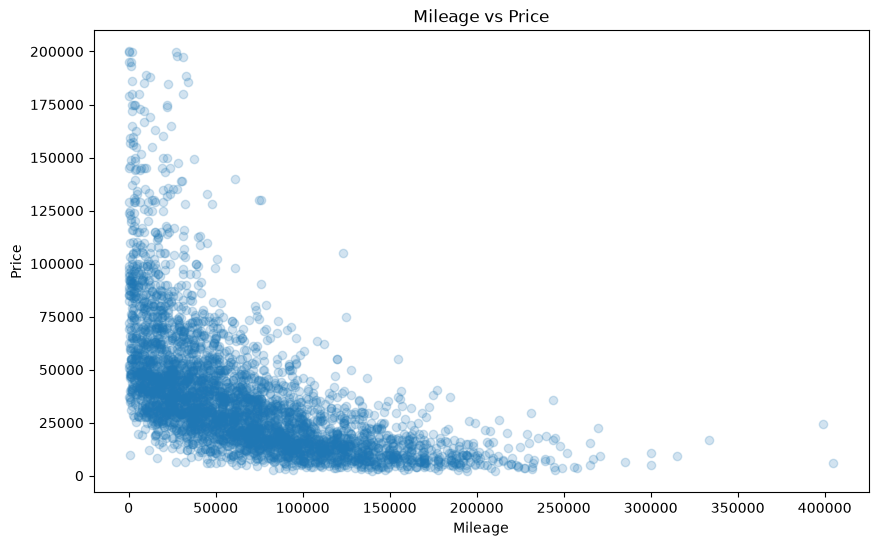

In [79]:
plt.figure(figsize=(10, 6))

plt.scatter(df.milage , df.price , alpha=0.2)

plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Mileage vs Price")

plt.show()

## ✂️ Train & Test Split

- To evaluate how well our model performs on unseen data, we split the dataset into training and testing sets.

- The training set is used to train the model, while the testing set is used to evaluate its performance.

In [80]:
msk = np.random.rand(len(df)) < 0.8
train = df[msk]
test = df[~msk]

## 📐 Polynomial Regression

- Polynomial Regression is an extension of Linear Regression that can model non-linear relationships between variables.

- In this project, we use polynomial features to investigate whether a non-linear relationship between mileage and car price can improve the prediction.

In [81]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

train_x = np.asanyarray(train[['milage']])
train_y = np.asanyarray(train[['price']])

test_x = np.asanyarray(test[['milage']])
test_y = np.asanyarray(test[['price']])

print(train_x[:3])

poly = PolynomialFeatures(degree = 2)

train_x_poly = poly.fit_transform(train_x)
train_x_poly

[[51000.]
 [34742.]
 [22372.]]


array([[1.00000000e+00, 5.10000000e+04, 2.60100000e+09],
       [1.00000000e+00, 3.47420000e+04, 1.20700656e+09],
       [1.00000000e+00, 2.23720000e+04, 5.00506384e+08],
       ...,
       [1.00000000e+00, 5.37050000e+04, 2.88422702e+09],
       [1.00000000e+00, 2.11600000e+03, 4.47745600e+06],
       [1.00000000e+00, 3.30000000e+04, 1.08900000e+09]], shape=(3151, 3))

## 📌 Model Coefficients & Intercept

- After fitting the Polynomial Regression model, we can examine the coefficients and intercept learned by the model.

In [82]:
clf = linear_model.LinearRegression()
train_y_ = clf.fit(train_x_poly , train_y)

print('Coefficients :' , clf.coef_)
print('Intercept :' , clf.intercept_)

Coefficients : [[ 0.00000000e+00 -6.71723229e-01  1.78863338e-06]]
Intercept : [69205.1401868]


## 📈 Visualizing the Polynomial Regression

- To better understand the model, we plot the Polynomial Regression curve together with the original data points.

- This allows us to visually compare the learned non-linear relationship with the actual data.

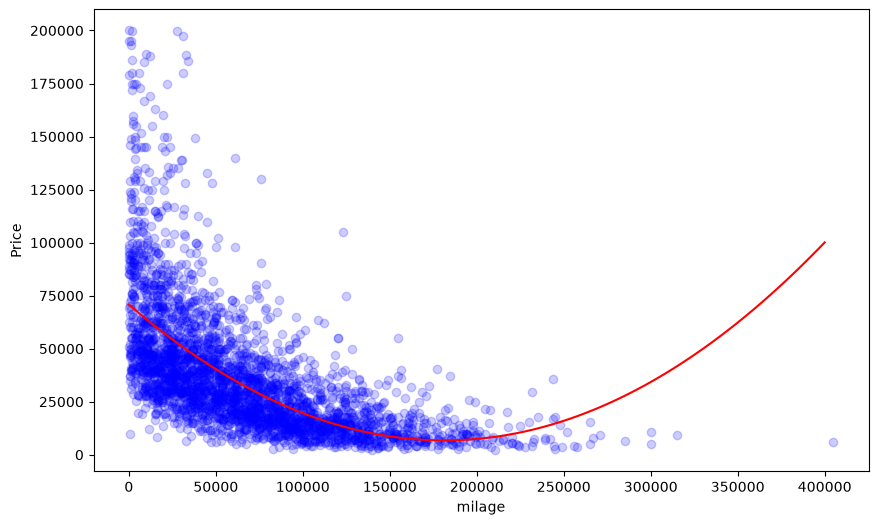

In [72]:
plt.figure(figsize = (10 , 6))

plt.scatter(train.milage , train.price , color = 'blue' , alpha = 0.2)

XX = np.arange(0 , 400000 , 10)
YY = clf.intercept_[0] + clf.coef_[0][1] * XX + clf.coef_[0][2] * np.power(XX , 2)

plt.plot(XX , YY , 'r-')
plt.ylabel('Price')
plt.xlabel('milage')

plt.show()

## 🎯 Model Prediction

- In this section, we use the trained Polynomial Regression model to predict car prices for the test data.

In [73]:
new_car = [[120000]]

new_car_poly = poly.transform(new_car)

prediction = train_y_.predict(new_car_poly)

print(prediction)

[[14074.91264632]]


In [74]:
from sklearn.metrics import r2_score

test_x_poly = poly.fit_transform(test_x)
test_y_ = clf.predict(test_x_poly)

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y,test_y_ ) )

Mean absolute error: 15708.05
Residual sum of squares (MSE): 536311356.17
R2-score: 0.40
